Piezo Step Peak Time: [0.000588 0.000632 0.00068  0.000726 0.000766 0.000806 0.000849 0.000898
 0.000942 0.000983 0.001024 0.001072 0.001125 0.001183 0.001228 0.001275
 0.001317 0.001365 0.001406 0.001451 0.0015  ]
Contact Peak Time: [0.000942 0.000997 0.001061 0.001112 0.001182 0.001234 0.00129  0.001365
 0.001447 0.001521 0.001577 0.001631 0.001687 0.001738 0.001805 0.001868
 0.001921 0.001976 0.002048 0.002098]


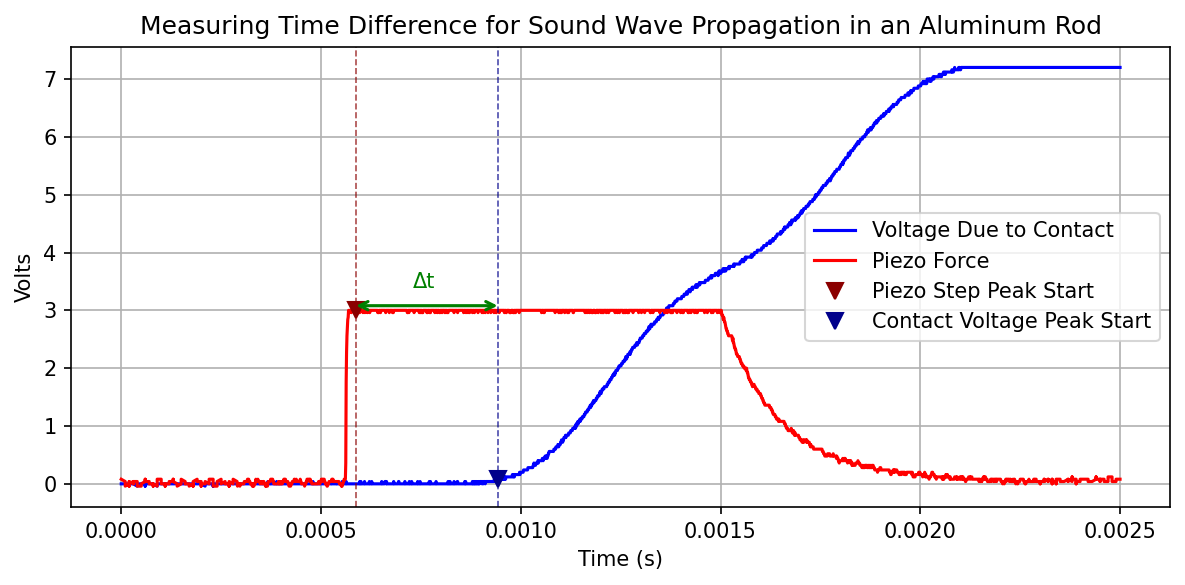

time: 0.00035400000000000004 s


In [50]:
import matplotlib.pyplot as plt
import numpy as np
import scipy
import scipy.signal as signal
from scipy.signal import find_peaks
import scipy.io as sio

path = "/content/lab2copperdata.csv"
data = np.genfromtxt(path, delimiter=',', names='time, voltage, piezo')

t = data['time'] + 0.00129 #adjusting for trigger point time for both data sets
voltage = data['voltage']
piezo = data['piezo']

fig, ax = plt.subplots(figsize=(8,4), dpi=150)

ax.plot(t, voltage, color='blue', label="Voltage Due to Contact")
ax.plot(t, piezo, color='red', label="Piezo Force")

peaks, properties = find_peaks(piezo, height=2.9, distance=40) # same for both metals
print("Piezo Step Peak Time:", t[peaks])

contact_peak, properties = find_peaks(voltage, height=0.06, distance=50) #height of 0.06 for copper and 0.20005 for aluminum; distance of 50 for copper and () for aluminum
print("Contact Peak Time:", t[contact_peak])

ax.plot(t[peaks[0]], piezo[peaks[0]], "v", color='darkred', markersize=8, label="Piezo Step Peak Start")
ax.plot(t[contact_peak[0]], voltage[contact_peak[0]], "v", color='darkblue', markersize=8, label="Contact Voltage Peak Start")
ax.axvline(t[peaks[0]], color='darkred', linestyle='--', linewidth=0.8, alpha=0.7)
ax.axvline(t[contact_peak[0]], color='darkblue', linestyle='--', linewidth=0.8, alpha=0.7)

t1 = t[peaks[0]]
t2 = t[contact_peak[0]]
y_mid = (piezo[peaks[0]] + voltage[contact_peak[0]])

ax.annotate('', xy=(t2, y_mid), xytext=(t1, y_mid), arrowprops=dict(arrowstyle='<->', color='green', lw=1.5, shrinkA=0, shrinkB=0))

ax.annotate('Δt', xy=(((t1+t2)/2 - 0.000035), (y_mid*1.1)),color='green', arrowprops=None)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Volts')
ax.set_title('Measuring Time Difference for Sound Wave Propagation in an Aluminum Rod')
ax.grid()
fig.tight_layout()
plt.legend()
plt.show()

deltat = (t2 - t1)
print("time:", deltat, "s")